# Tutorial: Conditional Sequencing Agent Workflows with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root  --port 9999 --ip=0.0.0.0`
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace 2_Conditional_Sequence_Pattern.ipynb`

This walkthrough demonstrates how to build and orchestrate a `Conditional Sequencing pipeline of agents` using the **AgentGrid SDKs**. We focus on the **Feature/Bug Traige Agents** 

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama etc) without changing your agent's core logic. The models which are hosted in AIOS as blocks or the 3rd party models like OpenAI/Gemini etc also can be accessed via the `agents_llm` library. As we will use `DSpy Library` for Agentic Programming, we have created a custom class to wrap the `agents_llm` library and provide a more user-friendly interface for model inference `AIOS_DSPy_LMs` custom class

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent.

### Core Data Structures
- **`AgentTask`**: Contains the `job_data` (payload) and metadata.
- **`AgentResult`**: Packages the output or error state.

### The `Context` Object
Every agent is initialized with a `Context`, providing communication handles:
1. **`p2p_manager`**: Synchronous or asynchronous peer-to-peer messaging. The Agent P2P Module enables decentralized, real-time communication between AI agents using WebSocket and HTTP. It supports direct messaging, API calls, file transfer, and remote task execution, making it ideal for distributed multi-agent coordination
2. **`delegator`**: Offloading tasks to specialized workers.
3. **`direct`**: Submitting tasks directly to other without central brokers

### Class Structure

In [ ]:
# sample_agent.py
import logging
import uuid
from typing import List, Optional

from core.agent_executor import AgentTask, AgentResult
from core.main import main
from core.agent_executor import Context

log = logging.getLogger(__name__)


class SampleAgent:

    def __init__(self, subject, context: Context) -> None:
        self.subject = subject
        self.context = context

    def get_muxer(self):
        return None

    def on_preprocess(self, task: AgentTask) -> Optional[List[AgentTask]]:

        text = task.job_data.get("text")
        if not text:
            log.warning(
                "Task %s has no 'text' in job_data, skipping.", task.task_id)
            return None

        return [task]

    def on_data(self, task: AgentTask) -> AgentResult:

        try:
            text = task.job_data["text"]
            out = text.upper()

            if self.context.subject_id == "uppercase-002":

                # agent P2P
                op_x = {}

                op_x = self.context.p2p_manager.send_and_wait_sync(
                    task.task_id, subject_id="uppercase-003",
                    task_data={"text": out + "World!"}
                )

                # using delegate
                op2 = self.context.delegator.submit_and_wait(
                    subject_id="uppercase-003", session_id=str(uuid.uuid4()), task_id=task.task_id, task_data={"text": out}
                )

                # agent direct (doesn't return the result to the caller)
                self.context.direct.submit(to="uppercase-003", session_id=str(uuid.uuid4()), task=task, job_data={
                    "text": "out " + "World!"
                })


                return AgentResult(
                    task_id=task.task_id,
                    job_output=op_x,
                    job_output_metadata={"length": len(out)},
                    is_error=False,
                )

            else:

                return AgentResult(
                    task_id=task.task_id,
                    job_output={"text": out},
                    job_output_metadata={"length": len(out)},
                    is_error=False,
                )

        except Exception as e:
            log.exception("Error processing task %s: %s", task.task_id, e)
            return AgentResult(
                task_id=task.task_id,
                is_error=True,
                error_data={"stage": "on_data", "message": str(e)},
            )


main(SampleAgent)


### FLOW
1. Use the Base Class Template shared above, and define(specific task) what the agent Class will do with the helps of AI Models and DSPy Library 
2. Use the communication entities to pass on the result of this agent to either next agents ro return the response back to user 
3. Build the docker and push to registry
4. Register the Agent to registry
5. Deploy the Agent Via Deployer
6. Do inference request to the First Agent/Agents

---

## 3. Case Study: Coding Task with Feature or Bug Traige Using Conditional Sequential Flow

The goal is to add a conditional check between specialized agents and move the shared "state" upon condition and aggregate the output to be shared to user.

### Flow Architecture
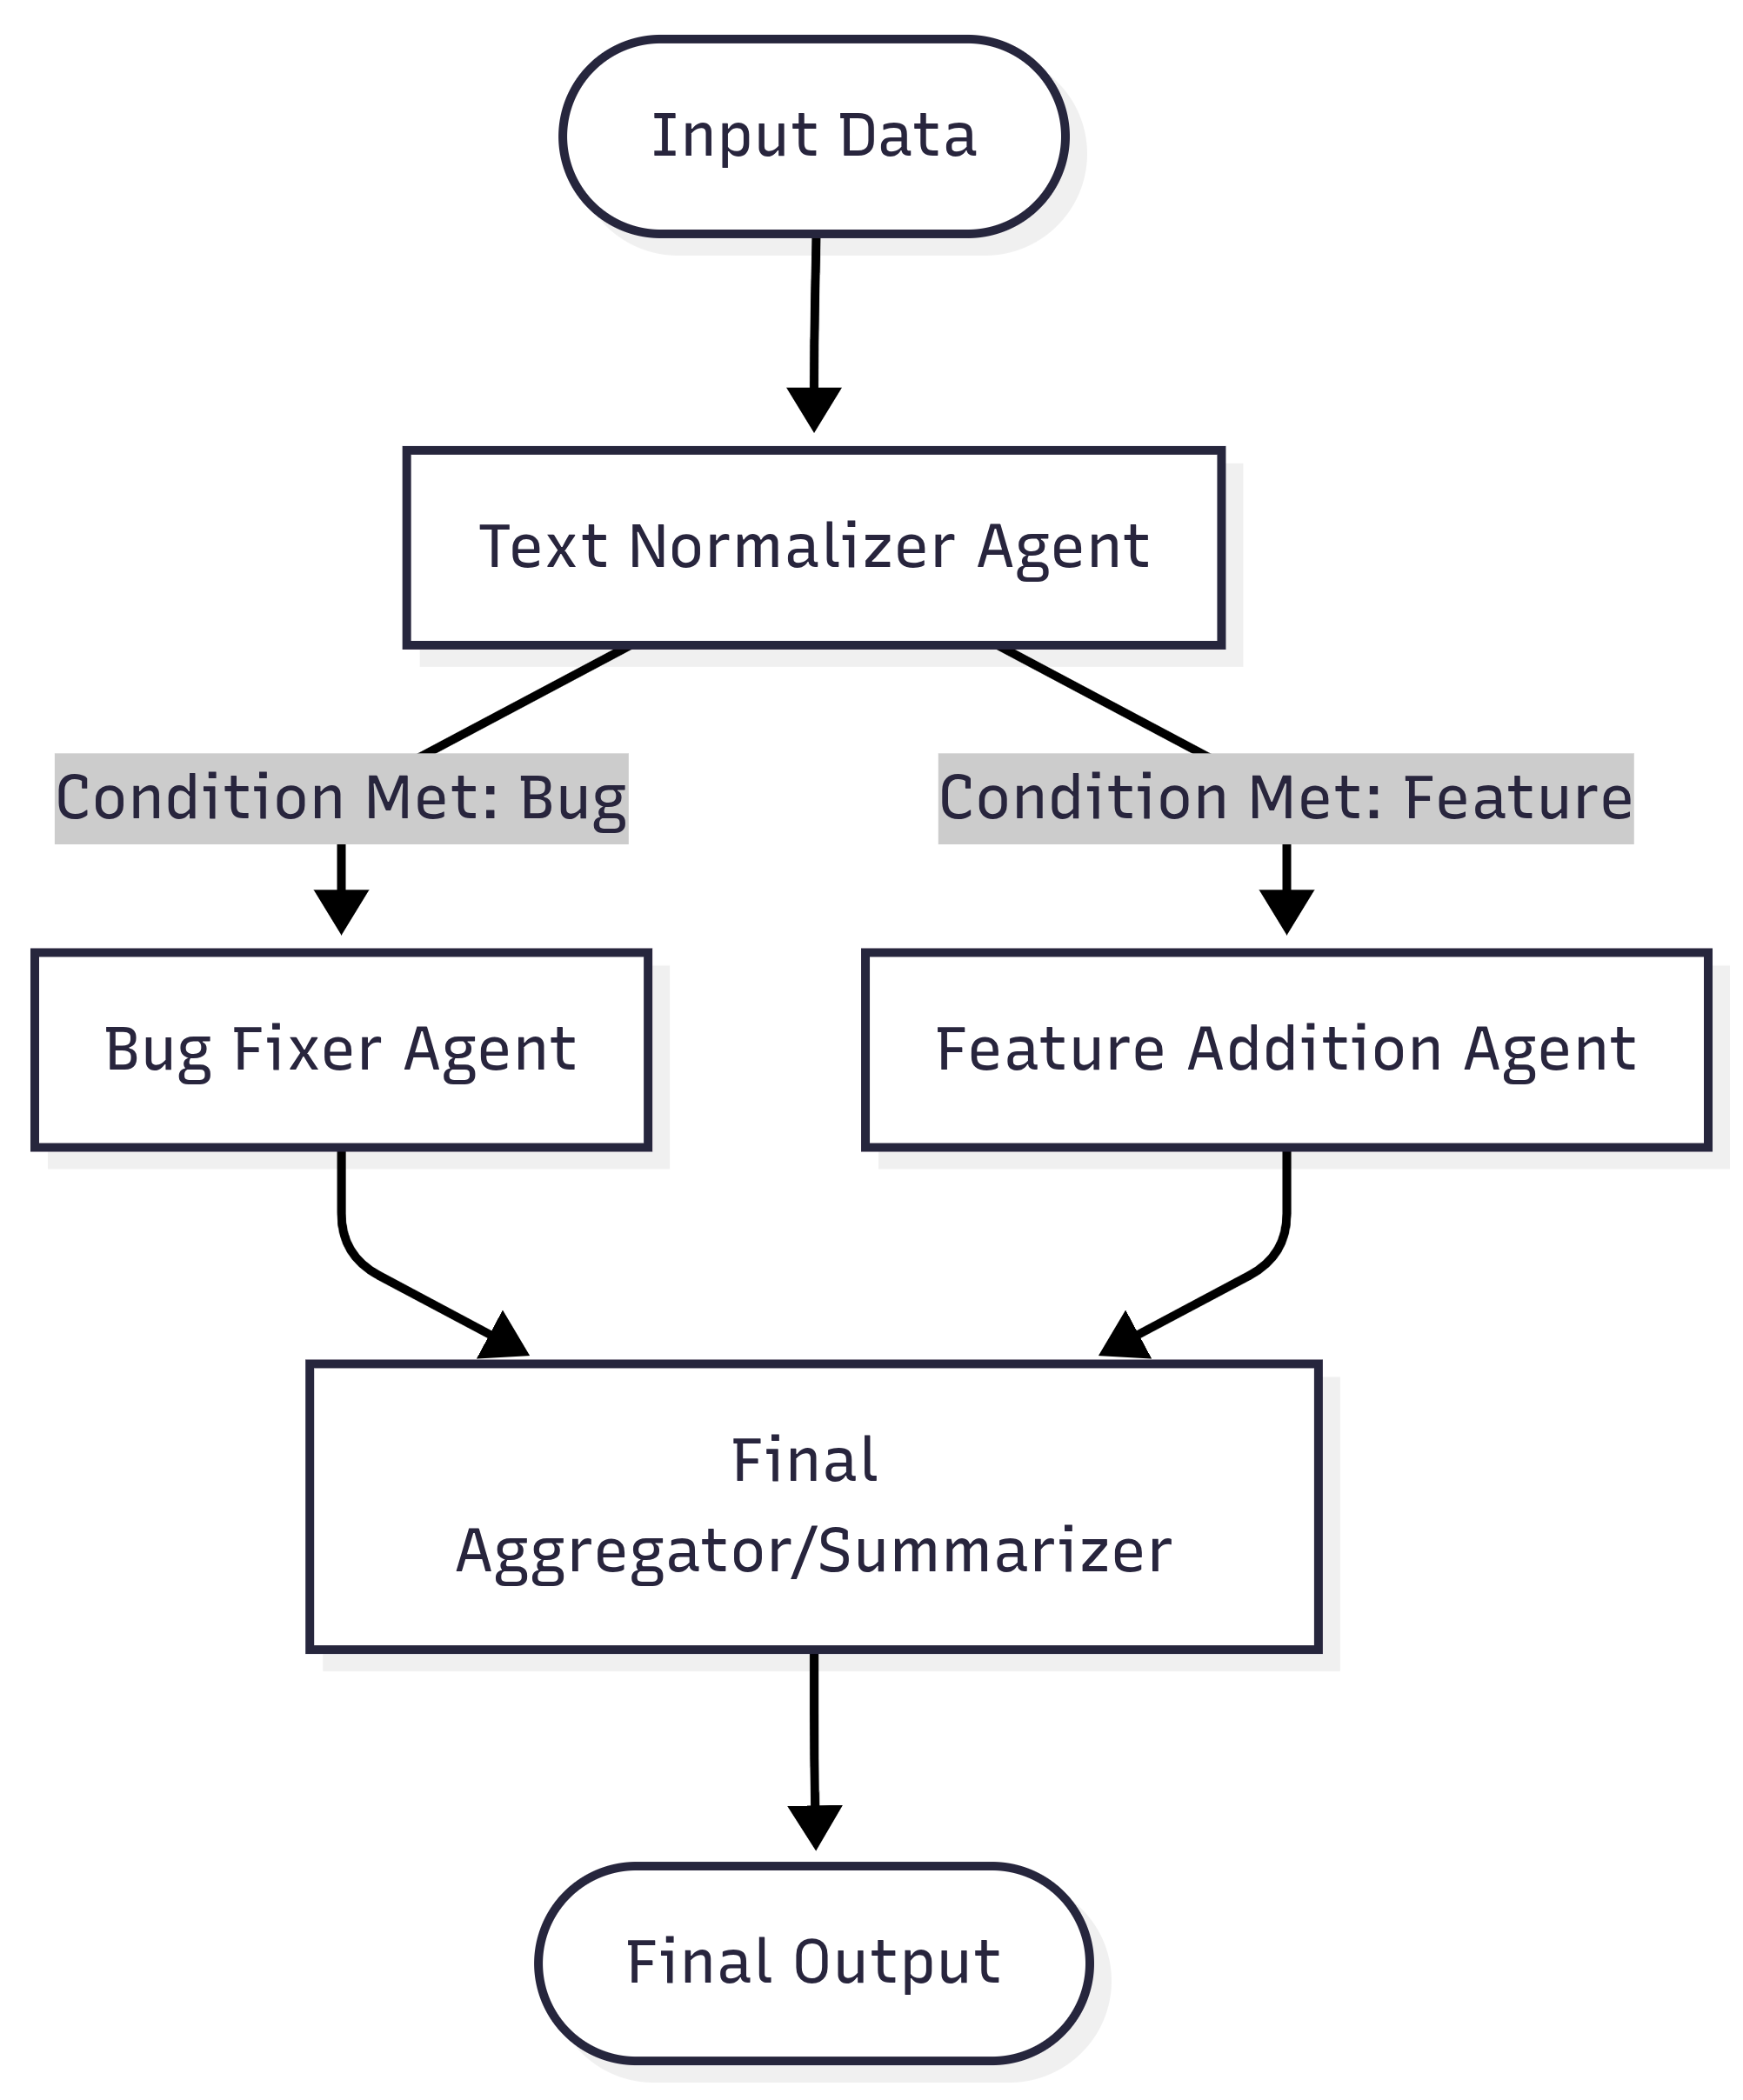

### Agent Roles & Constraints

#### A. Code Text Normalizer Agent
- **Input**: `piece of code with bug or feature request` (Raw Text).
- **DSPy Signature**: Normalize the text by fix obvious casing and spacing or correct glaring typos or expand common infra abbreviations
- **Routing Decision**: Decide whether a bug or feature request from users input with semantic check
- **Output**: Returns a Normalized Text to eith `Bug Fixer Agent` or `Feature Request Agent`.
- **Code**: [agent_codingtask_code_text_normalizer.py](../../agent_codes/agent_codingtask_code_text_normalizer.py)

#### B. Bug Fixer Agent
- **Input**: Normalized Text.
- **DSPy Signature**: Fix the bug and provide with details summary of the fix
- **Output**: Returns a JSON with Markdown output for summary,update code with fix etc.
- **Code**: [agent_codingtask_bug_fixer.py](../../agent_codes/agent_codingtask_bug_fixer.py)

#### C. Feature Addition Agent
- **Input**: Normalized Text.
- **DSPy Signature**: Add the feature to the code with markdown formatting and improved_code.
- **Output**: Returns a JSON with Markdown output for summary,update code with improvements etc..
- **Code**: [agent_codingtask_feature_improver.py](../../agent_codes/agent_codingtask_feature_improver.py)

#### D. Final Aggregator Agent
- **Input**: Previous stage output.
- **DSPy Signature**: Extract Short descriptive title, one_line_summary,improved_code.
- **Output**: Returns a JSON with Markdown output for summary,update code with improvements etc..
- **Code**: [agent_codingtask_final_aggregator.py](../../agent_codes/agent_codingtask_final_aggregator.py)

---

## 4. Execution Pipeline
1. **Build all the dockers**: Build the dockers using the bashscript provided i.e [build_meetingplanner_and_push.bash](../../agent_codes/build_meetingplanner_and_push.bash).
2. **Registration**: Agents are registered in the cluster via [register-agents.sh](../../agents_registration/2_condition_sequence_feature_bugs_triage/2_normalizer_agent1/register_agent.sh) for each agents.
3. **Deployment**: Containers are spun up using [deploy-agents.sh](../../agents_registration/2_condition_sequence_feature_bugs_triage/2_normalizer_agent1/deploy_agent.sh) for each agents.
4. **Trigger**: An initial `input` is sent to the **Brainstormer** via a API call, starting the chain reaction [inference_request.sh](../../agents_registration/2_condition_sequence_feature_bugs_triage/inference_request.sh)
5. **All in One**: Run [all.bash](../../agents_registration/2_condition_sequence_feature_bugs_triage/all.bash) to do 
    - `1. Remove agents if already running` 
    - `2. Unregister agent` 
    - `3. Register agent` 
    - `4. Deploy agents again` 

#### Run all.bash

In [ ]:
%%bash
cd ../../agents_registration/2_condition_sequence_feature_bugs_triage
bash all.bash

#### Check for pods in agents namespace

In [ ]:
%%bash
kubectl get pods -n agents

#### To check logs of pods

In [ ]:
%%bash
kubectl logs -f -n agents --tail 100 {POD_NAME} agent-core

##### Check Containers in a Pod

In [ ]:
kubectl get pod -n agents <PODNAME> -o jsonpath='{.spec.containers[*].name}'

##### Executor Containers
- executor: ratelimiting, config management, load balancing, autoscaling etc
- Scouter: responsible for scouting jobs in Job Exchange
 
* User can define the policy for above 

#### Trigger the First agent

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/2_condition_sequence_feature_bugs_triage
echo "$PWD"
bash inference_request.sh

#### To Remove the Agent Pods

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/2_condition_sequence_feature_bugs_triage
echo "$PWD"
bash remove-agents.sh